# CIFAR-10 CNN — Träning & Utvärdering

Den här notebooken innehåller hela arbetsflödet för CNN-modellen i CIFAR-10-projektet:

1. Utforskande dataanalys (EDA) av CIFAR-10-datasetet
2. Inladdning och förbehandling av data (via `data_loader.py`)
3. Bygge av CNN-arkitekturen (via `model.py`)
4. Träning av modellen
5. Utvärdering av modellens prestanda (confusion matrix, felanalys m.m.)
6. Analys av eventuella problem och möjliga förbättringar

Notebooken är strukturerad i numrerade sektioner. Varje kodcell har en kort förklaring innan sig och en "Vad vi ser."-cell efter, som sammanfattar resultatet på ett lättförståeligt sätt.

## 1. Utforskande dataanalys (EDA)

Innan vi bygger den återanvändbara preprocessing-koden (`data_loader.py`) vill vi förstå hur CIFAR-10-datasetet faktiskt ser ut: hur bilderna är strukturerade, hur klasserna är fördelade, och hur bilderna ser ut visuellt. Detta hjälper oss att upptäcka eventuella problem tidigt (t.ex. obalanserade klasser eller konstiga pixelvärden) och ger bra underlag till presentationens "beskriv datasetet"-del.

In [1]:
# Läser CIFAR-10 direkt från de nedladdade pickle-filerna, istället för att
# gå via tf.keras.datasets.cifar10.load_data(). Detta bypassar Kerasgrimman
# interna cache-/hash-hantering, som visat sig vara opålitlig i den här
# TensorFlow-versionen (fortsatte försöka ladda ner trots att en giltig,
# hash-verifierad lokal kopia redan fanns).
#
# Filformatet är dokumenterat på https://www.cs.toronto.edu/~kriz/cifar.html:
# varje batch-fil är en "picklad" Python-dict med nycklarna b'data'
# (10000 bilder x 3072 värden: 1024 röda + 1024 gröna + 1024 blåa pixlar)
# och b'labels' (10000 heltalsetiketter, 0-9).

import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

CIFAR_DIR = os.path.expanduser("~/.keras/datasets/cifar-10-batches-py")


def unpickle(file_path):
    """Läser en enskild CIFAR-10 batch-fil och returnerar dess dict."""
    with open(file_path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def load_batch(file_path):
    """
    Läser en batch-fil och omformar bilddatan från den platta
    (N, 3072)-formen till (N, 32, 32, 3) - dvs N bilder, 32x32 pixlar, 3 färgkanaler.
    """
    batch = unpickle(file_path)
    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    # Rådatan är (N, 3072): första 1024 = rött, nästa 1024 = grönt, sista 1024 = blått.
    # Omforma till (N, 3, 32, 32) och byt sedan ordning på axlarna till (N, 32, 32, 3),
    # vilket är standardformatet (channels-last) som TensorFlow/Keras förväntar sig.
    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return images, labels


# Läs in de 5 träningsbatcharna och slå ihop dem till en enda array
train_batches = [load_batch(os.path.join(CIFAR_DIR, f"data_batch_{i}")) for i in range(1, 6)]
x_train_raw = np.concatenate([images for images, _ in train_batches], axis=0)
y_train_raw = np.concatenate([labels for _, labels in train_batches], axis=0).reshape(-1, 1)

# Läs in testbatchen
x_test_raw, y_test_raw = load_batch(os.path.join(CIFAR_DIR, "test_batch"))
y_test_raw = y_test_raw.reshape(-1, 1)

print(f"Train images shape: {x_train_raw.shape}")   # förväntat: (50000, 32, 32, 3)
print(f"Train labels shape: {y_train_raw.shape}")    # förväntat: (50000, 1)
print(f"Test images shape:  {x_test_raw.shape}")     # förväntat: (10000, 32, 32, 3)
print(f"Test labels shape:  {y_test_raw.shape}")     # förväntat: (10000, 1)
print(f"Pixel value range:  {x_train_raw.min()} - {x_train_raw.max()}")  # förväntat: 0 - 255

Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)
Pixel value range:  0 - 255


**Vad vi ser.**

Vi har nu laddat in hela CIFAR-10-datasetet från de lokala pickle-filerna: 50 000 träningsbilder och 10 000 testbilder, precis som förväntat enligt datasetets officiella dokumentation.

Varje bild har formen `(32, 32, 3)` - det betyder 32x32 pixlar med 3 färgkanaler (röd, grön, blå). Etiketterna har formen `(N, 1)`, alltså en enda kolumn med ett heltal (0-9) per bild som anger vilken av de 10 klasserna bilden tillhör.

Pixelvärdena ligger mellan 0 och 255, vilket är standard för rå bilddata (8-bitars färgdjup per kanal). Det här är alltså fortfarande "rådata" - inget normaliserat eller förbehandlat än. Den förbehandlingen (skala om till 0-1, dela upp i train/val/test) gör vi i nästa steg, i den återanvändbara modulen `data_loader.py`.

**Bakgrund:** Vi läser filerna direkt via en egen `unpickle`/`load_batch`-funktion istället för `tf.keras.datasets.cifar10.load_data()`, eftersom den senare hade problem med att ladda ner från Torontos server (segt nätverk + inkonsekvent lokal cache-hantering i just den här Keras-versionen). Vår egen lösning är enklare att felsöka och kräver ingen nätverksåtkomst alls.

## 2. Klassnamn och klassfördelning

Innan vi tittar på bilderna vill vi bekräfta att datasetet är balanserat - det vill säga att varje klass har ungefär lika många bilder. Ett obalanserat dataset kan göra att modellen blir bättre på att känna igen vissa klasser än andra, vilket är viktigt att känna till innan vi börjar träna.

In [2]:
# CIFAR-10 klasser i indexordning (0-9), enligt den officiella dokumentationen
# på https://www.cs.toronto.edu/~kriz/cifar.html
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Räkna antal bilder per klass i träningsdatan
unique, counts = np.unique(y_train_raw, return_counts=True)

for class_idx, count in zip(unique, counts):
    print(f"{CLASS_NAMES[class_idx]:12s}: {count} bilder")

airplane    : 5000 bilder
automobile  : 5000 bilder
bird        : 5000 bilder
cat         : 5000 bilder
deer        : 5000 bilder
dog         : 5000 bilder
frog        : 5000 bilder
horse       : 5000 bilder
ship        : 5000 bilder
truck       : 5000 bilder


**Vad vi ser.**

Datasetet är helt balanserat - varje klass har exakt 5 000 bilder i träningsdatan, av totalt 50 000. Det betyder att modellen inte kommer att gynnas eller missgynnas av att någon klass har fler eller färre exempel att lära sig från.

Det här är bra nyheter för oss: vi behöver inte hantera obalanserad data (t.ex. genom att vikta klasser olika eller duplicera underrepresenterade klasser). Vi kan gå vidare med standardmetoder för träning utan extra försiktighetsåtgärder på den fronten.

## 3. Exempelbilder per klass

För att få en känsla för hur bilderna faktiskt ser ut visar vi en exempelbild från varje klass. Detta hjälper oss att bekräfta att bilddatan är korrekt inläst (rätt färger, rätt orientering) och ger en bra utgångspunkt att visa upp i presentationen när vi beskriver datasetet.

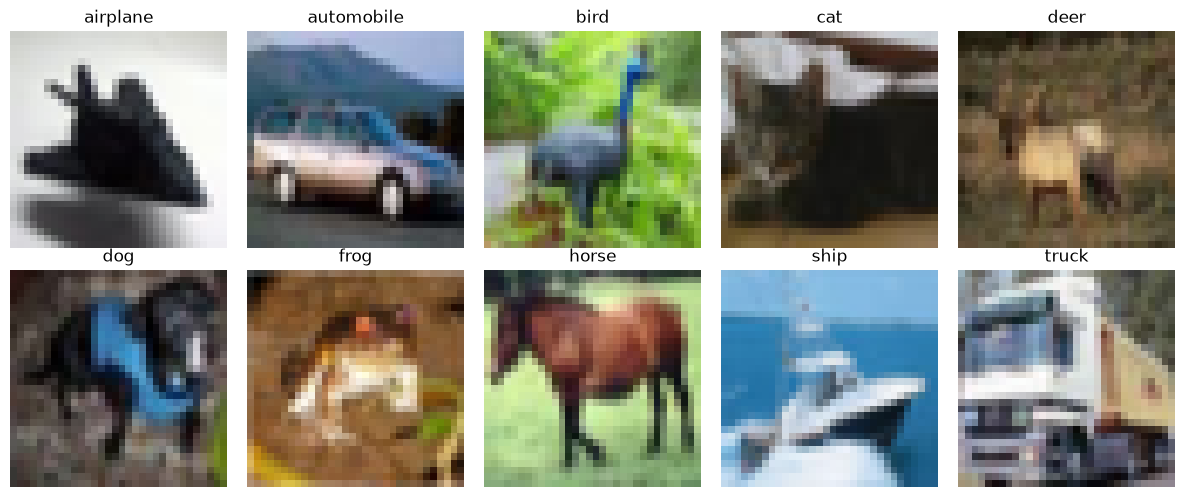

In [3]:
# Visa en exempelbild per klass, för att bekräfta att bilddatan är korrekt
# inläst (rätt färger, rätt orientering) och för att få en visuell känsla
# för hur låg upplösningen (32x32 pixlar) faktiskt är.

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx, ax in enumerate(axes.flat):
    # Hitta index för första bilden som tillhör denna klass
    idx = np.where(y_train_raw.flatten() == class_idx)[0][0]
    ax.imshow(x_train_raw[idx])
    ax.set_title(CLASS_NAMES[class_idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Vad vi ser.**

Vi ser en exempelbild för var och en av de 10 klasserna: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Färgerna och orienteringen ser korrekta ut - flygplanet ser ut som ett flygplan, bilen som en bil, och så vidare. Det bekräftar att vår `unpickle`/`load_batch`-funktion läser in bilddatan korrekt (rätt ordning på färgkanalerna och rätt omformning från den platta 3072-pixel-vektorn till en 32x32x3-bild).

Man ser också tydligt hur låg upplösningen faktiskt är (32x32 pixlar) - bilderna är ganska suddiga/pixliga jämfört med vanliga fotografier. Det här är en viktig egenskap hos CIFAR-10 som gör klassificeringen svårare än den skulle vara med högupplösta bilder, och något vi kan nämna i presentationen som en av datasetets utmaningar.

## 4. Testa data_loader-modulen

I den här sektionen importerar vi den återanvändbara funktionen `load_cifar10()`
från `model/src/data_loader.py` istället för att duplicera inläsnings- och
förbehandlingskoden här i notebooken. Vi kör funktionen och kontrollerar att
shapes, värdeintervall och uppdelningen i tränings-/validerings-/testset ser
ut som förväntat.

In [4]:
# Importerar den återanvändbara data_loader-modulen. Notebooken ligger i
# model/notebooks/, så vi lägger till model/src/ i sökvägen för att kunna
# importera modulen därifrån.
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "src")))

from data_loader import load_cifar10

(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_cifar10()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Pixel value range: {x_train.min()} - {x_train.max()}")
print(f"Exempel på en label (one-hot): {y_train[0]}")

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 10)
x_val shape:   (5000, 32, 32, 3)
y_val shape:   (5000, 10)
x_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 10)
Pixel value range: 0.0 - 1.0
Exempel på en label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


**Vad vi ser.**

Vi har nu bekräftat att `data_loader.py`-modulen fungerar korrekt och gör precis det den ska:

- **Uppdelningen stämmer:** 45 000 bilder i träningsset, 5 000 i valideringsset (dvs 10% av de ursprungliga 50 000 träningsbilderna, precis som vi ställde in med `val_size=0.1`), och 10 000 i testset. Testsetet är orört sedan tidigare — det är samma 10 000 bilder som CIFAR-10 alltid reserverar för slutgiltig utvärdering.

- **Normaliseringen fungerar:** pixelvärdena ligger nu mellan 0.0 och 1.0, istället för det ursprungliga intervallet 0-255. Detta är viktigt eftersom neurala nätverk tränar snabbare och mer stabilt när indata har små, konsekventa värden istället för stora heltal. Om vi hade matat in råa pixelvärden (0-255) direkt hade det kunnat leda till instabila gradienter under träningen.

- **One-hot encoding fungerar:** exemplet `[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]` visar att bilden tillhör klass 8 (ettan sitter på index 8, om vi räknar från 0). Innan var labeln bara ett enda heltal (t.ex. `8`), men nu är den omvandlad till en vektor med 10 positioner — en per klass — där exakt en position är 1 och resten är 0. Det här formatet krävs eftersom vi kommer använda `categorical_crossentropy` som loss-funktion, vilken förväntar sig att modellens output (en sannolikhet per klass) kan jämföras direkt mot en sådan one-hot-vektor.

- **Ingen dubblettkod längre:** notebooken behöver inte längre innehålla egen inläsnings- och förbehandlingslogik — allt sker nu via ett enda anrop till `load_cifar10()`. Det gör att om vi senare behöver ändra något i förbehandlingen (t.ex. justera valideringsandelen, eller lägga till data-augmentering), räcker det att ändra på ett ställe i `data_loader.py`, istället för att leta upp och ändra på flera ställen.

Med detta är data-pipelinen komplett och verifierad. Nästa steg blir att börja bygga och träna själva CNN-modellen.

## 5. CNN-modellarkitektur

I den här sektionen importerar vi den återanvändbara funktionen `build_model()`
från `model/src/model.py`, istället för att duplicera arkitektur- och
kompileringskoden här i notebooken.

Arkitekturen består av 3 convolutional-block med ökande filterdjup
(32 → 64 → 128), där varje block kombinerar Conv2D, BatchNormalization,
MaxPooling och Dropout, följt av ett fullt anslutet klassificeringshuvud.
Modellen kompileras med Adam-optimizer, categorical crossentropy som
loss-funktion (eftersom etiketterna är one-hot-encodade), och accuracy
som mätvärde.

In [5]:
# Importerar den återanvändbara build_model-funktionen från model.py.
# Notebooken ligger i model/notebooks/, så vi lägger till model/src/
# i sökvägen för att kunna importera modulen därifrån (samma mönster
# som för data_loader-importen i Sektion 4).
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "src")))

from model import build_model

model = build_model()
model.summary()

Model: "cifar10_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Vad vi ser.

Modellsammanfattningen visar exakt samma totala antal parametrar som när vi först prototypade arkitekturen (552 362 totalt, 551 466 tränbara, 896 icke-tränbara). Det bekräftar att `build_model()`-funktionen i `model.py` bygger precis samma CNN-arkitektur som beskrevs ovan — bara definierad i en återanvändbar modul istället för direkt i notebooken.

**En detalj att notera:** lagernamnen har högre nummer (t.ex. `conv2d_6`, `batch_normalization_6` istället för att börja på `conv2d`, `batch_normalization`). Detta beror på att Keras numrerar lager löpande inom en och samma notebook-session — om flera modeller byggs efter varandra utan att kernelen startas om fortsätter räkningen uppåt istället för att börja om. Numreringen påverkar inte hur modellen fungerar eller tränas; om man startar om notebookens kernel (Restart Kernel) och kör om alla celler i ordning kommer lagren istället numreras från början (`conv2d`, `conv2d_1`, `conv2d_2` osv.).

## 6. Data augmentation

För att motverka overfitting under en längre träningsomgång använder vi data
augmentation - slumpmässiga, lätta transformationer (spegling, rotation, zoom)
som appliceras på träningsbilderna vid varje epok. Detta gör att modellen aldrig
ser exakt samma bild två gånger, vilket tvingar den att lära sig mer generella
mönster istället för att memorera enskilda träningsbilder.

Augmentation ska ENDAST appliceras på träningsdatan - aldrig på validerings-
eller testdatan, eftersom vi vill utvärdera modellen på oförändrade, verkliga
bilder.

I den här sektionen importerar vi `build_augmentation_layer()` från
`data_loader.py` och visualiserar några exempel för att bekräfta att
transformationerna ser rimliga ut.

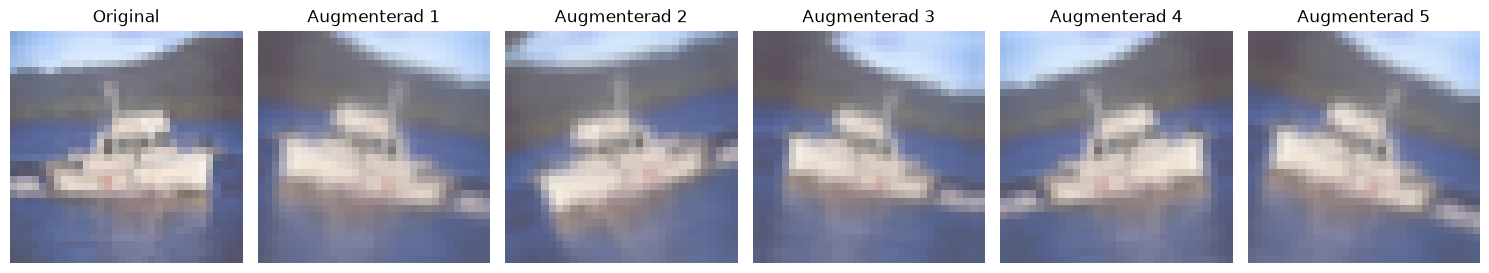

In [6]:
# Importerar augmentation-lagret från data_loader.py och applicerar det
# upprepade gånger på samma bild, för att visuellt bekräfta att
# transformationerna (flip, rotation, zoom) ser rimliga ut och inte
# förvränger bilden för mycket.
from data_loader import build_augmentation_layer

augmentation = build_augmentation_layer()

# Väljer en enskild träningsbild att augmentera flera gånger
sample_image = x_train[0:1]  # behåller batch-dimensionen: shape (1, 32, 32, 3)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

axes[0].imshow(sample_image[0])
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    augmented_image = augmentation(sample_image, training=True)
    axes[i].imshow(augmented_image[0].numpy())
    axes[i].set_title(f"Augmenterad {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Vad vi ser.

Vi ser originalbilden av en båt, följt av 5 augmenterade versioner av samma bild. Skillnaderna är subtila men synliga vid närmare granskning: båten är lite förskjuten och roterad olika i varje augmenterad version (t.ex. i "Augmenterad 4" syns båten något mer åt höger och lätt roterad jämfört med originalet). Det här är precis det beteende vi vill ha — transformationerna ska vara små nog att båten fortfarande är tydligt igenkännbar som en båt, men tillräckligt varierade för att ge modellen lite ny variation att träna på varje gång.

**Varför syns ingen tydlig spegling (flip) i just dessa 5 exempel?** `RandomFlip("horizontal")` väljer slumpmässigt, med 50% sannolikhet, om varje enskild bild ska speglas eller inte. Det är fullt möjligt (och inte alls ovanligt) att flera slumpdrag i rad råkar landa på "ingen spegling", precis som att slå krona fem gånger i rad med ett rättvist mynt inte är konstigt. Kör man cellen igen (vilket genererar nya slumpmässiga augmentationer) är chansen stor att minst en av de fem visar en spegelvänd båt.

**Slutsats:** augmentation-lagret fungerar som förväntat - det ger subtila, realistiska variationer av träningsbilderna utan att förvränga dem till oigenkännlighet.

### 6.1 Modell med data augmentation

Nu när vi har verifierat både arkitekturen (Sektion 5) och augmentation-lagret
ovan bygger vi om modellen med `build_model(augment=True)`, så att
augmentation-lagren ingår som de första lagren i modellen. Detta är versionen
av modellen som kommer användas för den riktiga träningsomgången.

In [7]:
# Bygger om modellen, nu med data augmentation inbyggd (augment=True är
# default). Vi kör model.summary() igen för att bekräfta att
# augmentation-lagret dyker upp som det första lagret i modellen.
model = build_model(augment=True)
model.summary()

Model: "cifar10_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Vad vi ser.

Ett nytt lager, `data_augmentation (Sequential)`, syns nu allra överst i modellen, före det första Conv2D-lagret. Det har **0 parametrar** - vilket är precis förväntat, eftersom augmentation-lagret inte lär sig något. Det utför bara slumpmässiga transformationer (spegling, rotation, zoom) på indatan; det finns inga vikter att träna.

Lagrets output-shape är `(None, 32, 32, 3)` - samma form som indatan. Det är logiskt: augmentation ändrar innehållet i bilden (pixelvärdena), men inte dess dimensioner.

**Totalt antal parametrar är oförändrat** (552 362 totalt, 551 466 tränbara, 896 icke-tränbara) jämfört med versionen utan augmentation. Det bekräftar att augmentation-lagret bara lagts till som ett extra steg i början av pipelinen, utan att påverka resten av arkitekturen.

Modellen är nu redo att tränas med data augmentation inbyggd - varje gång en träningsbild skickas genom modellen under `model.fit()` kommer den först genomgå en slumpmässig, lätt transformation innan den når de faktiska convolutional-lagren.